# Offline Activity: Probabilities

## Probabilities with Bayes Theorem

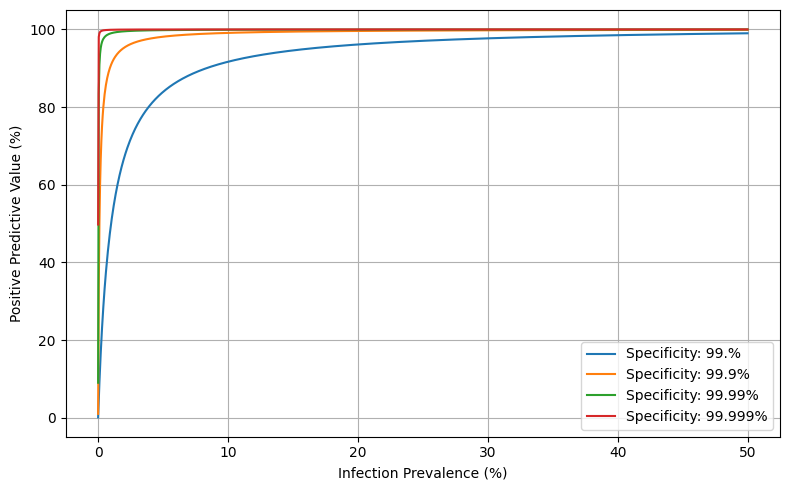

In [22]:
import matplotlib.pyplot as plt
import numpy as np

prevalence = np.linspace(0.00001, 0.5, 1000)
specificities = [0.99, 0.999, 0.9999, 0.99999]
sensitivity = 0.99

plt.figure(figsize=(8, 5))

for n, spec in enumerate(specificities):
    ppv = (sensitivity * prevalence) / (sensitivity * prevalence + (1 - spec) * (1 - prevalence))
    plt.plot(prevalence * 100, ppv * 100, label=f'Specificity: 99.{'9'*n}%')

plt.xlabel('Infection Prevalence (%)')
plt.ylabel('Positive Predictive Value (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Integer calculations

In [24]:
prevalence = 0.1
specificity = 0.999
sensitivity = 0.99
initial_population = 1000000
infected = initial_population * prevalence
true_positives = infected * sensitivity
false_positives = (initial_population - infected) * (1 - sensitivity)
ppv = true_positives / (true_positives + false_positives)
print(f"True Positives: {int(true_positives)}")
print(f"False Positives: {int(false_positives)}")
print(f"Positive Predictive Value: {ppv * 100:.2f}%")



True Positives: 99000
False Positives: 9000
Positive Predictive Value: 91.67%


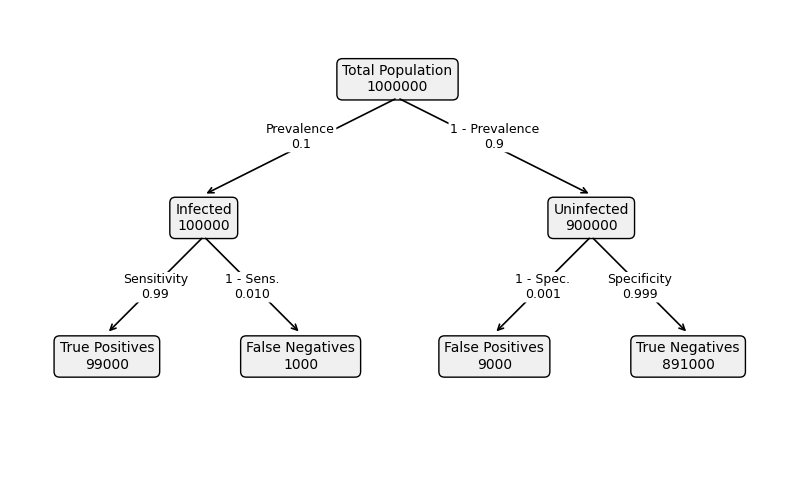

In [25]:
# Visualization made mostly with Gemini 3 Pro

# Define the data labels for each node in the tree
labels = {
    'root': f'Total Population\n{initial_population}',
    'inf': f'Infected\n{int(infected)}',
    'uninf': f'Uninfected\n{int(initial_population - infected)}',
    'tp': f'True Positives\n{int(true_positives)}',
    'fn': f'False Negatives\n{int(infected - true_positives)}',
    'fp': f'False Positives\n{int(false_positives)}',
    'tn': f'True Negatives\n{int(initial_population - infected - false_positives)}'
}

# Define the relative positioning for each node on a 2D plane
positions = {
    'root': (0.5, 0.85),
    'inf': (0.25, 0.55),
    'uninf': (0.75, 0.55),
    'tp': (0.125, 0.25),
    'fn': (0.375, 0.25),
    'fp': (0.625, 0.25),
    'tn': (0.875, 0.25)
}

# Initialize figure without axes
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')

# Render nodes with bounding boxes
box_style = dict(boxstyle="round,pad=0.4", edgecolor="black", facecolor="#f0f0f0")
for key, pos in positions.items():
    ax.text(pos[0], pos[1], labels[key], ha="center", va="center", bbox=box_style, fontsize=10)

# Define properties for directional vectors
arrow_props = dict(arrowstyle="->", color="black", lw=1.2)
text_box_style = dict(boxstyle="round,pad=0.1", facecolor="white", edgecolor="none")

# Render vectors from Root to Level 1 (Infection Status)
ax.annotate("", xy=(0.25, 0.6), xytext=(0.5, 0.81), arrowprops=arrow_props)
ax.annotate("", xy=(0.75, 0.6), xytext=(0.5, 0.81), arrowprops=arrow_props)

# Annotate vectors with prevalence rates
ax.text(0.375, 0.725, f'Prevalence\n{prevalence}', ha="center", va="center", fontsize=9, bbox=text_box_style)
ax.text(0.625, 0.725, f'1 - Prevalence\n{1-prevalence}', ha="center", va="center", fontsize=9, bbox=text_box_style)

# Render vectors from Level 1 (Infected) to Level 2 (Test Results)
ax.annotate("", xy=(0.125, 0.3), xytext=(0.25, 0.51), arrowprops=arrow_props)
ax.annotate("", xy=(0.375, 0.3), xytext=(0.25, 0.51), arrowprops=arrow_props)

# Annotate vectors with sensitivity parameters
ax.text(0.1875, 0.4, f'Sensitivity\n{sensitivity}', ha="center", va="center", fontsize=9, bbox=text_box_style)
ax.text(0.3125, 0.4, f'1 - Sens.\n{1-sensitivity:.3f}', ha="center", va="center", fontsize=9, bbox=text_box_style)

# Render vectors from Level 1 (Uninfected) to Level 2 (Test Results)
ax.annotate("", xy=(0.625, 0.3), xytext=(0.75, 0.51), arrowprops=arrow_props)
ax.annotate("", xy=(0.875, 0.3), xytext=(0.75, 0.51), arrowprops=arrow_props)

# Annotate vectors with specificity parameters
ax.text(0.6875, 0.4, f'1 - Spec.\n{1-specificity:.3f}', ha="center", va="center", fontsize=9, bbox=text_box_style)
ax.text(0.8125, 0.4, f'Specificity\n{specificity}', ha="center", va="center", fontsize=9, bbox=text_box_style)

# Export diagram
plt.show()